# 네트워크 침입 탐지 — MLflow Pipeline v9

## 가설

개별 Infilteration Flow가 Benign과 겹치더라도 동일 서비스(`Protocol + Dst Port`)의
과거 1·5·30분 행동과 비교하면 차이가 드러날 수 있습니다. v6의 알려진 공격 라우터는
그대로 유지하고, 남은 Benign/Infilteration 후보만 서비스 윈도우 모델로 판별합니다.

원본 가공 데이터에는 Src/Dst IP가 없으므로 호스트별 집계 대신 서비스별 집계를 사용합니다.
모든 윈도우는 현재 시각을 제외한 과거 행만 사용합니다. 1차 모델이 높게 오판한 Benign은
Hard Negative로 선별해 2차 학습에서 가중치를 높입니다.


In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

HYPOTHESIS_ID = "v9"
HYPOTHESIS = "service_past_windows_with_hard_negative_mining"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()
PROJECT_NAME = cwd.parent.name if cwd.name == "notebooks" else "network-classification"
PROJECT_DIR = WORK_ROOT / PROJECT_NAME
DATA_BASE = WORK_ROOT / "datasets"

def has_temporal_train(path: Path) -> bool:
    return (path / "processed" / "train_temporal_v5.parquet").exists()

preferred = DATA_BASE / PROJECT_NAME
if has_temporal_train(preferred):
    DATA_ROOT = preferred
else:
    matches = [p for p in DATA_BASE.iterdir() if p.is_dir() and has_temporal_train(p)]
    if len(matches) != 1:
        raise RuntimeError(f"Temporal 데이터 프로젝트를 결정할 수 없습니다: {matches}")
    DATA_ROOT = matches[0]

PROCESSED_DIR = DATA_ROOT / "processed"
TRAIN_TEMPORAL = PROCESSED_DIR / "train_temporal_v5.parquet"
TEST_TEMPORAL = PROCESSED_DIR / "test_temporal_v5.parquet"
TRAIN_SERVICE = PROCESSED_DIR / "train_service_temporal_v9.parquet"
TEST_SERVICE = PROCESSED_DIR / "test_service_temporal_v9.parquet"
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
KNOWN_ATTACKS = ["Brute Force", "DDOS", "DoS"]
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20
KNOWN_ATTACK_THRESHOLD = 0.45
INF_THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
POSITIVE_MULTIPLIERS = [0.10, 0.25, 0.50]
HARD_NEGATIVE_WEIGHTS = [1.0, 2.0, 4.0]
HARD_NEGATIVE_QUANTILE = 0.90

GLOBAL_CONTEXT_FEATURES = [
    "prev_distinct_ts_gap_s",
    "prior_events_10s_per_million",
    "prior_events_60s_per_million",
    "prior_events_300s_per_million",
    "prior_flow_pkts_s_mean_60s",
    "prior_flow_byts_s_mean_60s",
    "prior_total_pkts_mean_60s",
]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
SERVICE_CONTEXT_FEATURES = [
    "service_prev_ts_gap_s",
    "service_prior_events_60s_per_million",
    "service_prior_events_300s_per_million",
    "service_prior_events_1800s_per_million",
    "service_prior_flow_pkts_s_mean_300s",
    "service_prior_flow_byts_s_mean_300s",
    "service_prior_total_pkts_mean_300s",
    "service_prior_flow_duration_mean_300s",
]
SERVICE_DEVIATION_FEATURES = [
    "service_flow_pkts_log_deviation",
    "service_flow_byts_log_deviation",
    "service_total_pkts_log_deviation",
    "service_duration_log_deviation",
]
SERVICE_FEATURES = [*SERVICE_CONTEXT_FEATURES, *SERVICE_DEVIATION_FEATURES]

V6_BASELINE = {
    "weighted_f1_attacks": 0.9202514012197288,
    "macro_f1_attacks": 0.7541476007767233,
    "accuracy": 0.9089381451548372,
    "infilteration_precision": 0.09265507396833636,
    "infilteration_recall": 0.4594594594594595,
    "infilteration_f1": 0.15421166306695464,
    "benign_to_infilteration_fp": 3496,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids-{HYPOTHESIS_ID}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Project    :", PROJECT_NAME)
print("Data root  :", DATA_ROOT)
print("Output     :", OUTPUT_DIR)
print("Experiment :", EXPERIMENT_NAME)


Project    : network-classification
Data root  : /home/jovyan/work/datasets/ 📁 network-classification
Output     : /home/jovyan/work/network-classification/outputs/v9
Experiment : network-classification-ids-v9


## 1. 서비스별 과거 윈도우 Parquet 생성

동일 timestamp의 행은 서로 참조하지 않습니다. 서비스 집계는 데이터셋 크기 차이를 줄이기
위해 백만 행당 발생량으로 정규화합니다.


In [2]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def build_service_parquet(source: Path, target: Path):
    schema_version = "1"
    version_path = target.with_suffix(target.suffix + ".version")
    if (
        target.exists() and version_path.exists()
        and version_path.read_text().strip() == schema_version
        and target.stat().st_mtime >= source.stat().st_mtime
    ):
        print("[재사용]", target)
        return

    src = parquet_expr(source)
    dst = sql_path(target)
    query = f'''
        COPY (
            WITH service_ts AS (
                SELECT
                    "Protocol" AS protocol_key,
                    "Dst Port" AS port_key,
                    "Timestamp" AS ts,
                    COUNT(*)::DOUBLE AS n_events,
                    SUM(CASE WHEN isfinite("Flow Pkts/s") THEN "Flow Pkts/s" ELSE 0 END) AS sum_pkts_s,
                    SUM(CASE WHEN isfinite("Flow Byts/s") THEN "Flow Byts/s" ELSE 0 END) AS sum_byts_s,
                    SUM(COALESCE("Tot Fwd Pkts", 0) + COALESCE("Tot Bwd Pkts", 0)) AS sum_total_pkts,
                    SUM(COALESCE("Flow Duration", 0)) AS sum_duration
                FROM {src}
                GROUP BY 1, 2, 3
            ),
            globals AS (
                SELECT COUNT(*)::DOUBLE AS total_rows FROM {src}
            ),
            context AS (
                SELECT
                    s.protocol_key, s.port_key, s.ts,
                    COALESCE(epoch(s.ts - LAG(s.ts) OVER service_order), 0) AS service_prev_ts_gap_s,
                    COALESCE(1000000.0 * SUM(s.n_events) OVER w60 / g.total_rows, 0) AS service_prior_events_60s_per_million,
                    COALESCE(1000000.0 * SUM(s.n_events) OVER w300 / g.total_rows, 0) AS service_prior_events_300s_per_million,
                    COALESCE(1000000.0 * SUM(s.n_events) OVER w1800 / g.total_rows, 0) AS service_prior_events_1800s_per_million,
                    COALESCE(SUM(s.sum_pkts_s) OVER w300 / NULLIF(SUM(s.n_events) OVER w300, 0), 0) AS service_prior_flow_pkts_s_mean_300s,
                    COALESCE(SUM(s.sum_byts_s) OVER w300 / NULLIF(SUM(s.n_events) OVER w300, 0), 0) AS service_prior_flow_byts_s_mean_300s,
                    COALESCE(SUM(s.sum_total_pkts) OVER w300 / NULLIF(SUM(s.n_events) OVER w300, 0), 0) AS service_prior_total_pkts_mean_300s,
                    COALESCE(SUM(s.sum_duration) OVER w300 / NULLIF(SUM(s.n_events) OVER w300, 0), 0) AS service_prior_flow_duration_mean_300s
                FROM service_ts s
                CROSS JOIN globals g
                WINDOW
                    service_order AS (PARTITION BY s.protocol_key, s.port_key ORDER BY s.ts),
                    w60 AS (PARTITION BY s.protocol_key, s.port_key ORDER BY s.ts RANGE BETWEEN INTERVAL 60 SECOND PRECEDING AND INTERVAL 1 MICROSECOND PRECEDING),
                    w300 AS (PARTITION BY s.protocol_key, s.port_key ORDER BY s.ts RANGE BETWEEN INTERVAL 300 SECOND PRECEDING AND INTERVAL 1 MICROSECOND PRECEDING),
                    w1800 AS (PARTITION BY s.protocol_key, s.port_key ORDER BY s.ts RANGE BETWEEN INTERVAL 1800 SECOND PRECEDING AND INTERVAL 1 MICROSECOND PRECEDING)
            )
            SELECT r.*,
                c.service_prev_ts_gap_s,
                c.service_prior_events_60s_per_million,
                c.service_prior_events_300s_per_million,
                c.service_prior_events_1800s_per_million,
                c.service_prior_flow_pkts_s_mean_300s,
                c.service_prior_flow_byts_s_mean_300s,
                c.service_prior_total_pkts_mean_300s,
                c.service_prior_flow_duration_mean_300s
            FROM {src} r
            LEFT JOIN context c
              ON r."Protocol" IS NOT DISTINCT FROM c.protocol_key
             AND r."Dst Port" IS NOT DISTINCT FROM c.port_key
             AND r."Timestamp" = c.ts
            ORDER BY r."Timestamp", r."{ID_COL}"
        ) TO '{dst}' (FORMAT PARQUET, COMPRESSION ZSTD)
    '''
    started = time.time()
    with duckdb.connect() as con:
        con.execute(query)
    version_path.write_text(schema_version)
    print(f"[생성 완료] {target} ({time.time() - started:,.1f}s)")

build_service_parquet(TRAIN_TEMPORAL, TRAIN_SERVICE)
build_service_parquet(TEST_TEMPORAL, TEST_SERVICE)


[재사용] /home/jovyan/work/datasets/ 📁 network-classification/processed/train_service_temporal_v9.parquet
[재사용] /home/jovyan/work/datasets/ 📁 network-classification/processed/test_service_temporal_v9.parquet


In [3]:
with duckdb.connect() as con:
    checks = []
    for split, path in [("train", TRAIN_SERVICE), ("test", TEST_SERVICE)]:
        result = con.execute(f'''
            WITH x AS (
                SELECT "Timestamp", LAG("Timestamp") OVER () AS prev_ts,
                       {', '.join(SERVICE_CONTEXT_FEATURES)}
                FROM {parquet_expr(path)}
            )
            SELECT '{split}' AS split, COUNT(*) AS row_count,
                   COUNT(*) FILTER (WHERE "Timestamp" < prev_ts) AS order_violations,
                   COUNT(*) FILTER (WHERE {' OR '.join(f'{c} IS NULL OR NOT isfinite({c})' for c in SERVICE_CONTEXT_FEATURES)}) AS invalid_rows
            FROM x
        ''').df()
        checks.append(result)
service_checks = pd.concat(checks, ignore_index=True)
display(service_checks)
assert (service_checks["order_violations"] == 0).all()
assert (service_checks["invalid_rows"] == 0).all()


,split,row_count,order_violations,invalid_rows
0,train,4638804,0,0
1,test,1159701,0,0


## 2. 표본 로드, 편차 피처 및 시간 검증 분할


In [4]:
def load_sample(path: Path, n_rows: int):
    with duckdb.connect() as con:
        return con.execute(f'''
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

def add_ids_and_deviation_features(df: pd.DataFrame):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    if all(c in df.columns for c in flag_cols):
        values = {c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float) for c in flag_cols}
        syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
        rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
        urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
        total_flags = syn + ack + rst + fin + urg + psh + 1.0
        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags

    deviation_pairs = {
        "service_flow_pkts_log_deviation": ("Flow Pkts/s", "service_prior_flow_pkts_s_mean_300s"),
        "service_flow_byts_log_deviation": ("Flow Byts/s", "service_prior_flow_byts_s_mean_300s"),
        "service_total_pkts_log_deviation": (None, "service_prior_total_pkts_mean_300s"),
        "service_duration_log_deviation": ("Flow Duration", "service_prior_flow_duration_mean_300s"),
    }
    total_pkts = pd.to_numeric(df["Tot Fwd Pkts"], errors="coerce").fillna(0) + pd.to_numeric(df["Tot Bwd Pkts"], errors="coerce").fillna(0)
    for new_col, (current_col, baseline_col) in deviation_pairs.items():
        current = total_pkts if current_col is None else pd.to_numeric(df[current_col], errors="coerce").fillna(0)
        baseline = pd.to_numeric(df[baseline_col], errors="coerce").fillna(0)
        df[new_col] = np.log1p(np.clip(current, 0, None)) - np.log1p(np.clip(baseline, 0, None))

    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_and_deviation_features(load_sample(TRAIN_SERVICE, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
INFILTRATION_LABEL = next(c for c in classes if c.lower() in {"infiltration", "infilteration"})

class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
valid_mask = train_df["Timestamp"] > y_all.map(class_cutoffs)
train_mask = ~valid_mask

X_router = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES, *SERVICE_FEATURES], errors="ignore")
X_flow = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *GLOBAL_CONTEXT_FEATURES, *CALENDAR_FEATURES, *SERVICE_FEATURES], errors="ignore")
X_service = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore")
feature_frames = {"flow_only": X_flow, "service_context": X_service}
for frame in [X_router, *feature_frames.values()]:
    for column in CAT_FEATURES:
        if column in frame.columns:
            frame[column] = frame[column].astype("string")

split_distribution = pd.crosstab(np.where(valid_mask, "valid_late", "train_early"), y_all)
display(class_cutoffs.to_frame("cutoff"))
display(split_distribution)
print("Loaded:", train_df.shape)
print("Feature counts:", {k: v.shape[1] for k, v in feature_frames.items()})


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


Loaded: (250000, 74)
Feature counts: {'flow_only': 47, 'service_context': 66}


## 3. 모델·평가 함수


In [5]:
def make_preprocessor(frame):
    cat_cols = [c for c in CAT_FEATURES if c in frame.columns]
    num_cols = [c for c in frame.columns if c not in cat_cols]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_cols),
    ])

def make_lgbm(objective, class_weight=None, n_estimators=500):
    return LGBMClassifier(
        objective=objective,
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

def make_pipeline(frame, objective, class_weight=None, n_estimators=500):
    return Pipeline([
        ("preprocess", make_preprocessor(frame)),
        ("model", make_lgbm(objective, class_weight, n_estimators)),
    ])

def binary_weights(y, positive_multiplier, hard_indices=None, hard_weight=1.0):
    y = pd.Series(y).astype(int)
    counts = y.value_counts()
    weights = y.map({c: len(y) / (2.0 * n) for c, n in counts.items()}).astype(float)
    weights.loc[y == 1] *= positive_multiplier
    if hard_indices is not None and hard_weight != 1.0:
        selected = weights.index.intersection(pd.Index(hard_indices))
        weights.loc[selected] *= hard_weight
    return weights.to_numpy()

def evaluate_multiclass(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [(INFILTRATION_LABEL, "infilteration"), ("Brute Force", "bruteforce"), ("DDOS", "ddos"), ("DoS", "dos")]:
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[label], average=None, zero_division=0)
        metrics.update({f"{prefix}_precision": float(p[0]), f"{prefix}_recall": float(r[0]), f"{prefix}_f1": float(f[0])})
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    metrics["benign_to_infilteration_fp"] = int(np.sum((yt == "Benign") & (yp == INFILTRATION_LABEL)))
    return metrics


## 4. v6 알려진 공격 라우터 고정


In [6]:
y_attack_binary = (y_all != "Benign").astype(int)
attack_train_mask = train_mask & (y_all != "Benign")
attack_gate = make_pipeline(X_router, "binary", "balanced", 400)
subtype_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.asarray(attack_classes),
    y=y_all.loc[attack_train_mask].to_numpy(),
)
subtype_weights = dict(zip(attack_classes, subtype_weight_values.astype(float)))
attack_subtype = make_pipeline(X_router, "multiclass", subtype_weights, 500)
attack_gate.fit(X_router.loc[train_mask], y_attack_binary.loc[train_mask])
attack_subtype.fit(X_router.loc[attack_train_mask], y_all.loc[attack_train_mask])

valid_index = train_df.index[valid_mask]
y_valid = y_all.loc[valid_index]
valid_attack_probability = attack_gate.predict_proba(X_router.loc[valid_index])[:, 1]
valid_attack_subtype = attack_subtype.predict(X_router.loc[valid_index])
known_accept = np.isin(valid_attack_subtype, KNOWN_ATTACKS) & (valid_attack_probability >= KNOWN_ATTACK_THRESHOLD)
print("Known attacks accepted:", int(known_accept.sum()))


Known attacks accepted: 14758


## 5. 시간 분리 Hard Negative 탐색


In [7]:
residual_train_mask = train_mask & y_all.isin(["Benign", INFILTRATION_LABEL])
residual_train_index = train_df.index[residual_train_mask]
residual_y = (y_all.loc[residual_train_index] == INFILTRATION_LABEL).astype(int)

def mine_hard_negatives(frame, eligible_index, seed_offset=0):
    y = (y_all.loc[eligible_index] == INFILTRATION_LABEL).astype(int)
    ts = train_df.loc[eligible_index, "Timestamp"]
    cutoffs = ts.groupby(y).quantile(0.75)
    mine_mask = ts > y.map(cutoffs)
    base_idx = eligible_index[~mine_mask.to_numpy()]
    mine_idx = eligible_index[mine_mask.to_numpy()]
    base_y = (y_all.loc[base_idx] == INFILTRATION_LABEL).astype(int)

    model = make_pipeline(frame, "binary", None, 250)
    model.named_steps["model"].set_params(random_state=RANDOM_STATE + seed_offset)
    model.fit(frame.loc[base_idx], base_y, model__sample_weight=binary_weights(base_y, 0.5))
    benign_mine_idx = mine_idx[y_all.loc[mine_idx].eq("Benign").to_numpy()]
    scores = pd.Series(model.predict_proba(frame.loc[benign_mine_idx])[:, 1], index=benign_mine_idx)
    score_cutoff = float(scores.quantile(HARD_NEGATIVE_QUANTILE))
    hard_idx = scores.index[scores >= score_cutoff]
    return hard_idx, {
        "base_rows": len(base_idx), "mine_rows": len(mine_idx),
        "benign_mine_rows": len(benign_mine_idx), "hard_negative_rows": len(hard_idx),
        "hard_score_cutoff": score_cutoff,
    }

hard_negative_sets = {}
mining_rows = []
for offset, (feature_set, frame) in enumerate(feature_frames.items()):
    hard_idx, stats = mine_hard_negatives(frame, residual_train_index, offset)
    hard_negative_sets[feature_set] = hard_idx
    mining_rows.append({"feature_set": feature_set, **stats})
mining_summary = pd.DataFrame(mining_rows)
mining_summary.to_csv(OUTPUT_DIR / "v9_hard_negative_mining.csv", index=False, encoding="utf-8-sig")
display(mining_summary)


,feature_set,base_rows,mine_rows,benign_mine_rows,hard_negative_rows,hard_score_cutoff
0,flow_only,105471,35156,34374,3438,0.616456
1,service_context,105471,35156,34374,3438,0.999983


## 6. 피처·양성 가중치·Hard Negative 가중치 탐색


In [8]:
candidate_results = []
trained_models = {}
for feature_set, frame in feature_frames.items():
    hard_idx = hard_negative_sets[feature_set]
    for positive_multiplier in POSITIVE_MULTIPLIERS:
        for hard_weight in HARD_NEGATIVE_WEIGHTS:
            key = (feature_set, positive_multiplier, hard_weight)
            model = make_pipeline(frame, "binary", None, 350)
            weights = binary_weights(residual_y, positive_multiplier, hard_idx, hard_weight)
            started = time.time()
            model.fit(frame.loc[residual_train_index], residual_y, model__sample_weight=weights)
            train_seconds = time.time() - started
            probabilities = model.predict_proba(frame.loc[valid_index])[:, 1]
            trained_models[key] = model
            for threshold in INF_THRESHOLDS:
                residual_pred = np.where(probabilities >= threshold, INFILTRATION_LABEL, "Benign")
                final_pred = np.where(known_accept, valid_attack_subtype, residual_pred)
                candidate_results.append({
                    "feature_set": feature_set,
                    "positive_multiplier": positive_multiplier,
                    "hard_negative_weight": hard_weight,
                    "inf_threshold": threshold,
                    **evaluate_multiclass(y_valid, final_pred),
                    "train_seconds": train_seconds,
                })

search_df = pd.DataFrame(candidate_results)
search_df.to_csv(OUTPUT_DIR / "v9_candidate_search.csv", index=False, encoding="utf-8-sig")
display(search_df.sort_values(["infilteration_f1", "accuracy"], ascending=False).head(30))


,feature_set,positive_multiplier,hard_negative_weight,inf_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,train_seconds
172,service_context,0.10,1.0,0.10,0.921025,0.758033,0.868889,0.095261,0.778636,0.169753,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5746,4.226874
171,service_context,0.10,1.0,0.05,0.920951,0.757664,0.856566,0.093375,0.850708,0.168279,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6418,4.226874
191,service_context,0.10,2.0,0.10,0.920923,0.757523,0.867748,0.094033,0.774775,0.167711,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5800,4.195096
190,service_context,0.10,2.0,0.05,0.920888,0.757346,0.855365,0.092590,0.850708,0.167004,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6478,4.195096
210,service_context,0.10,4.0,0.10,0.920829,0.757051,0.868128,0.093038,0.761905,0.165826,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5771,4.291562
267,service_context,0.25,4.0,0.10,0.920824,0.757027,0.859786,0.092247,0.814672,0.165728,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6229,4.202574
271,service_context,0.25,4.0,0.30,0.920819,0.756999,0.884072,0.094710,0.658945,0.165615,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,4894,4.202574
231,service_context,0.25,1.0,0.20,0.920800,0.756905,0.875910,0.093517,0.709138,0.165242,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5341,4.192769
230,service_context,0.25,1.0,0.15,0.920781,0.756808,0.870529,0.092739,0.741313,0.164854,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5635,4.192769
286,service_context,0.50,1.0,0.10,0.920771,0.756756,0.863247,0.091949,0.786358,0.164646,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6034,4.315976


In [9]:
known_guards = (
    (search_df["bruteforce_f1"] >= 0.90)
    & (search_df["ddos_f1"] >= 0.98)
    & (search_df["dos_f1"] >= 0.90)
)
strict = search_df[
    known_guards
    & (search_df["accuracy"] >= 0.89)
    & (search_df["infilteration_recall"] >= 0.45)
    & (search_df["benign_to_infilteration_fp"] <= 4000)
]
relaxed = search_df[
    known_guards
    & (search_df["accuracy"] >= 0.87)
    & (search_df["infilteration_recall"] >= 0.35)
    & (search_df["benign_to_infilteration_fp"] <= 5500)
]
if len(strict):
    selection_tier, pool = "strict", strict
elif len(relaxed):
    selection_tier, pool = "relaxed", relaxed
else:
    selection_tier, pool = "fallback", search_df[known_guards]
    if pool.empty:
        selection_tier, pool = "fallback_guard_failed", search_df

champion_row = pool.sort_values(
    ["infilteration_f1", "infilteration_recall", "accuracy"], ascending=False
).iloc[0]
selected_key = (
    champion_row["feature_set"],
    float(champion_row["positive_multiplier"]),
    float(champion_row["hard_negative_weight"]),
)
selected_model = trained_models[selected_key]
selected_threshold = float(champion_row["inf_threshold"])
champion_metrics = {k: champion_row[k] for k in [
    "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
    "infilteration_precision", "infilteration_recall", "infilteration_f1",
    "bruteforce_precision", "bruteforce_recall", "bruteforce_f1",
    "ddos_precision", "ddos_recall", "ddos_f1",
    "dos_precision", "dos_recall", "dos_f1", "benign_to_infilteration_fp",
]}
print("Selection tier:", selection_tier)
print("Selected config:", selected_key, "threshold", selected_threshold)
print("Metrics:", champion_metrics)
print("Delta vs v6:", {k: float(champion_metrics[k]) - float(V6_BASELINE[k]) for k in V6_BASELINE if k in champion_metrics})


Selection tier: strict
Selected config: ('service_context', 0.5, 4.0) threshold 0.65
Metrics: {'weighted_f1_attacks': np.float64(0.9198307811802613), 'macro_f1_attacks': np.float64(0.7520343504819081), 'accuracy': np.float64(0.9014563495238858), 'infilteration_precision': np.float64(0.0862190812720848), 'infilteration_recall': np.float64(0.47104247104247104), 'infilteration_f1': np.float64(0.14575866188769415), 'bruteforce_precision': np.float64(0.8553147035779577), 'bruteforce_recall': np.float64(0.9963492546394889), 'bruteforce_f1': np.float64(0.9204609331084879), 'ddos_precision': np.float64(1.0), 'ddos_recall': np.float64(0.9884325230511316), 'ddos_f1': np.float64(0.9941826152938201), 'dos_precision': np.float64(0.9998013113451222), 'dos_recall': np.float64(0.9008234872896527), 'dos_f1': np.float64(0.9477351916376306), 'benign_to_infilteration_fp': np.int64(3879)}
Delta vs v6: {'weighted_f1_attacks': -0.000420620039467523, 'macro_f1_attacks': -0.0021132502948151277, 'accuracy': -0.

## 7. 산출물과 오류 분석


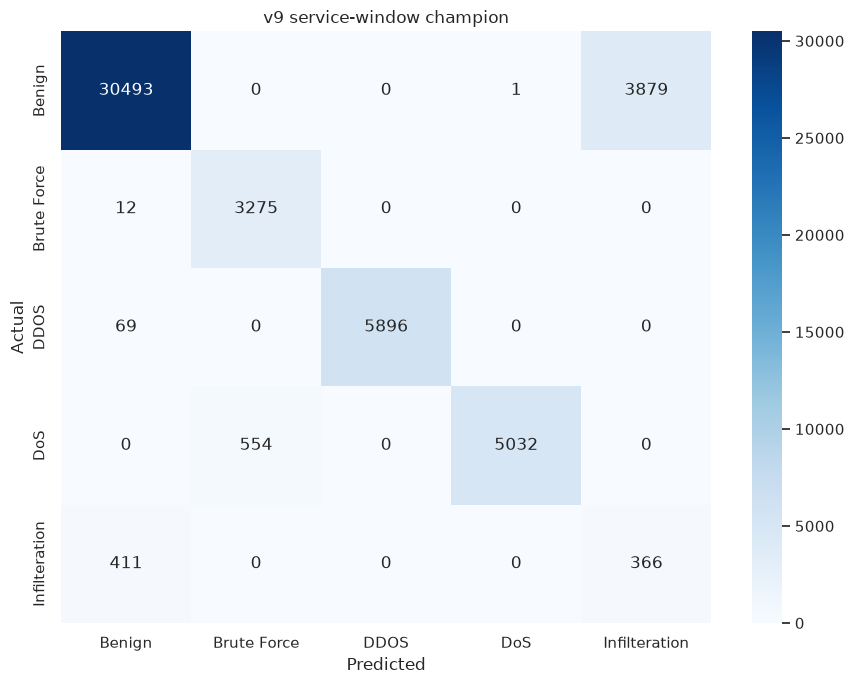

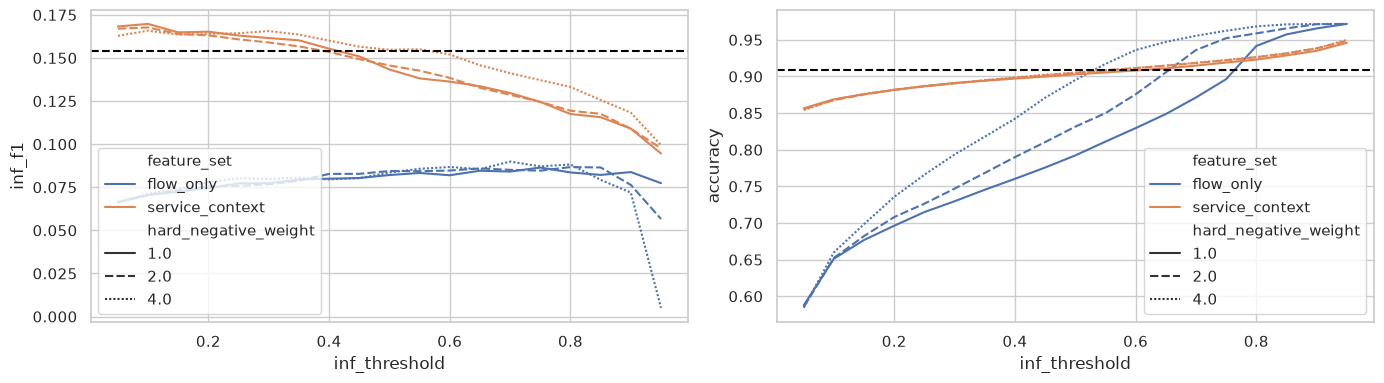

In [10]:
selected_frame = feature_frames[selected_key[0]]
selected_probability = selected_model.predict_proba(selected_frame.loc[valid_index])[:, 1]
selected_residual_pred = np.where(selected_probability >= selected_threshold, INFILTRATION_LABEL, "Benign")
selected_pred = np.where(known_accept, valid_attack_subtype, selected_residual_pred)

report_df = pd.DataFrame(classification_report(y_valid, selected_pred, output_dict=True, zero_division=0)).T
report_path = OUTPUT_DIR / "v9_champion_classification_report.csv"
report_df.to_csv(report_path, encoding="utf-8-sig")
cm = confusion_matrix(y_valid, selected_pred, labels=classes)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(title="v9 service-window champion", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
cm_path = OUTPUT_DIR / "v9_champion_confusion_matrix.png"
fig.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()

plot_df = search_df.groupby(["feature_set", "hard_negative_weight", "inf_threshold"], as_index=False).agg(
    inf_f1=("infilteration_f1", "max"), accuracy=("accuracy", "max")
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=plot_df, x="inf_threshold", y="inf_f1", hue="feature_set", style="hard_negative_weight", ax=axes[0])
sns.lineplot(data=plot_df, x="inf_threshold", y="accuracy", hue="feature_set", style="hard_negative_weight", ax=axes[1])
axes[0].axhline(V6_BASELINE["infilteration_f1"], ls="--", color="black", label="v6")
axes[1].axhline(V6_BASELINE["accuracy"], ls="--", color="black", label="v6")
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v9_service_hard_negative_tradeoff.png"
fig.savefig(tradeoff_path, dpi=160, bbox_inches="tight")
plt.show()


## 8. 2018-03-01 날짜 홀드아웃


In [11]:
holdout_train_mask = y_all.isin(["Benign", INFILTRATION_LABEL]) & (train_df["Timestamp"] < pd.Timestamp("2018-03-01"))
holdout_valid_mask = y_all.isin(["Benign", INFILTRATION_LABEL]) & (train_df["Timestamp"] >= pd.Timestamp("2018-03-01")) & (train_df["Timestamp"] < pd.Timestamp("2018-03-02"))
holdout_train_idx = train_df.index[holdout_train_mask]
holdout_valid_idx = train_df.index[holdout_valid_mask]
holdout_frame = feature_frames[selected_key[0]]
holdout_hard_idx, holdout_mining = mine_hard_negatives(holdout_frame, holdout_train_idx, 100)
holdout_y_train = (y_all.loc[holdout_train_idx] == INFILTRATION_LABEL).astype(int)
holdout_model = make_pipeline(holdout_frame, "binary", None, 350)
holdout_weights = binary_weights(holdout_y_train, selected_key[1], holdout_hard_idx, selected_key[2])
holdout_model.fit(holdout_frame.loc[holdout_train_idx], holdout_y_train, model__sample_weight=holdout_weights)
holdout_probability = holdout_model.predict_proba(holdout_frame.loc[holdout_valid_idx])[:, 1]
holdout_pred = (holdout_probability >= selected_threshold).astype(int)
holdout_y_valid = (y_all.loc[holdout_valid_idx] == INFILTRATION_LABEL).astype(int).to_numpy()
hp, hr, hf, _ = precision_recall_fscore_support(holdout_y_valid, holdout_pred, labels=[1], average=None, zero_division=0)
holdout_metrics = {
    "holdout_precision": float(hp[0]), "holdout_recall": float(hr[0]), "holdout_f1": float(hf[0]),
    "holdout_accuracy": float(accuracy_score(holdout_y_valid, holdout_pred)),
    "holdout_train_rows": len(holdout_train_idx), "holdout_valid_rows": len(holdout_valid_idx),
    "holdout_valid_infilteration": int(holdout_y_valid.sum()),
    "holdout_hard_negative_rows": len(holdout_hard_idx),
}
print("Holdout mining:", holdout_mining)
print("Date holdout:", holdout_metrics)
display(pd.crosstab(pd.Series(holdout_y_valid, name="actual"), pd.Series(holdout_pred, name="predicted")))


Holdout mining: {'base_rows': 105795, 'mine_rows': 35265, 'benign_mine_rows': 34864, 'hard_negative_rows': 3488, 'hard_score_cutoff': 0.9999803562103419}
Date holdout: {'holdout_precision': 0.6363636363636364, 'holdout_recall': 0.003035559410234172, 'holdout_f1': 0.006042296072507553, 'holdout_accuracy': 0.7215572482166607, 'holdout_train_rows': 141060, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306, 'holdout_hard_negative_rows': 3488}


predicted,0,1
actual,,
0,5961,4
1,2299,7


## 9. 가설 판정과 MLflow 기록


In [12]:
hypothesis_supported = (
    champion_metrics["infilteration_f1"] > V6_BASELINE["infilteration_f1"]
    and champion_metrics["infilteration_recall"] >= 0.45
    and champion_metrics["accuracy"] >= 0.89
    and champion_metrics["benign_to_infilteration_fp"] <= 4000
    and holdout_metrics["holdout_f1"] >= 0.15
)

summary_df = pd.DataFrame([
    {"model": "v6_baseline", **V6_BASELINE},
    {"model": "v9_service_hard_negative", **champion_metrics},
])
summary_path = OUTPUT_DIR / "v9_champion_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

with mlflow.start_run(run_name="v9_service_hard_negative_validation") as validation_run:
    mlflow.set_tags({
        "project": PROJECT_NAME, "hypothesis_id": HYPOTHESIS_ID, "hypothesis": HYPOTHESIS,
        "stage": "chronological_validation", "promotion_status": "candidate" if hypothesis_supported else "rejected",
        "champion_remains": "v9" if hypothesis_supported else "v6",
        "ip_columns_available": "false",
    })
    mlflow.log_params({
        "train_sample": TRAIN_SAMPLE, "feature_set": selected_key[0],
        "positive_multiplier": selected_key[1], "hard_negative_weight": selected_key[2],
        "hard_negative_quantile": HARD_NEGATIVE_QUANTILE, "infilteration_threshold": selected_threshold,
        "selection_tier": selection_tier, "known_attack_threshold": KNOWN_ATTACK_THRESHOLD,
    })
    mlflow.log_metrics({**{k: float(v) for k, v in champion_metrics.items()}, **holdout_metrics})
    for artifact in [
        OUTPUT_DIR / "v9_hard_negative_mining.csv", OUTPUT_DIR / "v9_candidate_search.csv",
        report_path, cm_path, tradeoff_path, summary_path,
    ]:
        mlflow.log_artifact(str(artifact))
    mlflow.sklearn.log_model(
        attack_gate, name="stage1_attack_gate",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        attack_subtype, name="stage1_attack_subtype",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        selected_model, name="stage2_service_hard_negative",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    validation_run_id = validation_run.info.run_id

print("Hypothesis supported:", hypothesis_supported)
print("Validation run:", validation_run_id)
display(summary_df)


2026/08/16 01:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/16 01:40:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/16 01:40:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v9_service_hard_negative_validation at: http://mlflow:5000/#/experiments/8/runs/616727bc6b4c4cf88025d8f219a92011
🧪 View experiment at: http://mlflow:5000/#/experiments/8
Hypothesis supported: False
Validation run: 616727bc6b4c4cf88025d8f219a92011


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_f1,ddos_f1,dos_f1,bruteforce_precision,bruteforce_recall,ddos_precision,ddos_recall,dos_precision,dos_recall
0,v6_baseline,0.920251,0.754148,0.908938,0.092655,0.459459,0.154212,3496,0.920461,0.994183,0.947735,NaN,NaN,NaN,NaN,NaN,NaN
1,v9_service_hard_negative,0.919831,0.752034,0.901456,0.086219,0.471042,0.145759,3879,0.920461,0.994183,0.947735,0.855315,0.996349,1.0,0.988433,0.999801,0.900823


## 10. 승인 시 재학습과 테스트 예측


In [13]:
final_run_id = None
submission_path = None
if hypothesis_supported:
    selected_frame = feature_frames[selected_key[0]]
    all_residual_idx = train_df.index[y_all.isin(["Benign", INFILTRATION_LABEL])]
    all_hard_idx, _ = mine_hard_negatives(selected_frame, all_residual_idx, 200)
    all_residual_y = (y_all.loc[all_residual_idx] == INFILTRATION_LABEL).astype(int)
    final_attack_gate = clone(attack_gate)
    final_attack_subtype = clone(attack_subtype)
    final_residual = clone(selected_model)
    with mlflow.start_run(run_name="v9_service_hard_negative_refit") as final_run:
        final_attack_gate.fit(X_router, (y_all != "Benign").astype(int))
        final_attack_subtype.fit(X_router.loc[y_all != "Benign"], y_all.loc[y_all != "Benign"])
        final_residual.fit(
            selected_frame.loc[all_residual_idx], all_residual_y,
            model__sample_weight=binary_weights(all_residual_y, selected_key[1], all_hard_idx, selected_key[2]),
        )
        mlflow.set_tags({"project": PROJECT_NAME, "hypothesis_id": HYPOTHESIS_ID, "stage": "refit", "promotion_status": "candidate"})
        mlflow.log_params({"source_validation_run_id": validation_run_id, "feature_set": selected_key[0], "threshold": selected_threshold})
        for model, name in [(final_attack_gate, "attack_gate"), (final_attack_subtype, "attack_subtype"), (final_residual, "residual")]:
            mlflow.sklearn.log_model(
                model, name=name,
                serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
            )
        final_run_id = final_run.info.run_id

    with duckdb.connect() as con:
        test_df = con.execute(f"SELECT * FROM {parquet_expr(TEST_SERVICE)}").df()
    test_df = add_ids_and_deviation_features(test_df)
    test_ids = test_df[ID_COL].copy()
    X_test_router = test_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES, *SERVICE_FEATURES], errors="ignore")
    X_test_flow = test_df.drop(columns=[TARGET, ID_COL, "Timestamp", *GLOBAL_CONTEXT_FEATURES, *CALENDAR_FEATURES, *SERVICE_FEATURES], errors="ignore")
    X_test_service = test_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore")
    test_frames = {"flow_only": X_test_flow, "service_context": X_test_service}
    for frame in [X_test_router, *test_frames.values()]:
        for column in CAT_FEATURES:
            if column in frame.columns:
                frame[column] = frame[column].astype("string")
    X_test_router = X_test_router[X_router.columns]
    X_test_selected = test_frames[selected_key[0]][selected_frame.columns]
    gate_prob = final_attack_gate.predict_proba(X_test_router)[:, 1]
    subtype = final_attack_subtype.predict(X_test_router)
    accept = np.isin(subtype, KNOWN_ATTACKS) & (gate_prob >= KNOWN_ATTACK_THRESHOLD)
    inf_prob = final_residual.predict_proba(X_test_selected)[:, 1]
    residual_pred = np.where(inf_prob >= selected_threshold, INFILTRATION_LABEL, "Benign")
    pred = np.where(accept, subtype, residual_pred)
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: pred}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v9.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    print("Submission:", submission_path, submission.shape)
else:
    rejection_path = OUTPUT_DIR / "REJECTED.md"
    rejection_path.write_text(
        "# v9 experiment status: rejected\n\n"
        "Do not promote v9; v6 remains champion.\n\n"
        f"- Infilteration precision / recall / F1: {champion_metrics['infilteration_precision']:.6f} / {champion_metrics['infilteration_recall']:.6f} / {champion_metrics['infilteration_f1']:.6f}\n"
        f"- Accuracy: {champion_metrics['accuracy']:.6f}\n"
        f"- Benign to Infilteration false positives: {int(champion_metrics['benign_to_infilteration_fp'])}\n"
        f"- Date holdout F1 / accuracy: {holdout_metrics['holdout_f1']:.6f} / {holdout_metrics['holdout_accuracy']:.6f}\n"
        f"- Validation run: `{validation_run_id}`\n",
        encoding="utf-8",
    )
    print("가설 기각:", rejection_path)

print("Final run:", final_run_id)
print("Submission:", submission_path)


가설 기각: /home/jovyan/work/network-classification/outputs/v9/REJECTED.md
Final run: None
Submission: None
